# 04. PyTorch 본학습 - ImageNet 사전학습 가중치 적용

이 노트북은 이미 완료된 EDA와 전처리 결과를 다시 수행하지 않고,
`224×224 grayscale PNG`와 AI-Hub JSON의 `filename`, `faceExp_uploader`를 연결하여
세 모델을 **ImageNet 사전학습 가중치에서 시작해 Fine-tuning**한다.

본학습 모델:
- MobileNetV3 Small
- EfficientNetB0
- ResNet18

공통 조건:
- Pretrained Weights: ImageNet DEFAULT
- Optimizer: Adam
- Learning Rate: 0.001
- Batch Size: 32
- 최대 Epoch: 30
- EarlyStopping patience: 5
- Scheduler: 사용하지 않음
- Weight Decay: 사용하지 않음
- Mixed Precision: 사용하지 않음
- `num_workers=0` (Windows + Jupyter 안정성 우선)

평가 및 시각화:
- CrossEntropy Loss
- Accuracy
- Precision
- Recall
- F1-score
- Confusion Matrix
- 모든 그래프는 **Matplotlib**으로 생성하고 `06_outputs/`에 PNG로 저장

> 전처리된 흑백 이미지는 컬러로 복원하지 않는다.  
> torchvision 모델 입력 형식에 맞추기 위해 같은 grayscale 값을 3채널로 복제한 뒤,
> ImageNet 사전학습 가중치에 맞는 정규화를 적용한다.

> **파일 덮어쓰기 방지:**  
> 이전 `weights=None` 실험 결과를 보존하기 위해, 이 pretrained 버전에서 저장되는 모델/CSV/그래프 파일명에는 `pretrained`를 붙인다.


## 1. 학습 환경 및 데이터 연결

- 1-1. 라이브러리 / GPU 확인
- 1-2. 프로젝트 경로 / 클래스 설정
- 1-3. grayscale PNG와 JSON 라벨 연결
- 1-4. 학습 직전 데이터 수 검증

여기서는 새로운 전처리를 하지 않고,
이미 만들어 둔 grayscale PNG와 `filename`, `faceExp_uploader`만 학습용으로 연결한다.

### 1-1. 라이브러리 / 랜덤 시드 / GPU 확인

필요한 라이브러리를 불러오고,
실행마다 결과 차이를 줄이기 위해 Python, NumPy, PyTorch의 랜덤 시드를 `42`로 고정한다.

그다음 현재 학습을 실행하는 집 PC에서
PyTorch가 CUDA와 RTX 3070 GPU를 정상 인식하는지 확인한다.

> 랜덤 시드를 고정해도 GPU 종류나 CUDA 연산 차이 때문에
> 집 PC와 직능원 PC 결과가 완전히 동일해지는 것은 아니다.
> 다만 모델 비교의 재현성과 비교 가능성을 높일 수 있다.

In [1]:
from pathlib import Path
import random
import json
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms
from PIL import Image

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
)


# --------------------------------------------------
# 재현성을 높이기 위한 랜덤 시드 고정
# --------------------------------------------------
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print("Random Seed:", SEED)

# Windows에서 한글 그래프 라벨 표시
plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

# PyTorch / CUDA 확인
print("PyTorch:", torch.__version__)
print("CUDA 사용 가능:", torch.cuda.is_available())
print("GPU 개수:", torch.cuda.device_count())

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("사용 장치:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))


Random Seed: 42
PyTorch: 2.5.1+cu121
CUDA 사용 가능: True
GPU 개수: 1
사용 장치: cuda
GPU: NVIDIA GeForce RTX 3070


### 1-2. 프로젝트 경로 및 감정 클래스 설정

기존 프로젝트 폴더의 이미지 / 라벨 / 모델 / 결과 경로를 지정하고,
7개 감정 클래스 순서를 정의한다.

In [2]:
# 프로젝트 기본 경로
PROJECT_ROOT = Path(r"D:\emotion_recognition_project")

# 기존 전처리된 grayscale PNG 경로
GRAY_TRAIN_DIR = (
    PROJECT_ROOT / "02_data" / "processed" / "grayscale_png" / "train"
)
GRAY_VALID_DIR = (
    PROJECT_ROOT / "02_data" / "processed" / "grayscale_png" / "valid"
)

# AI-Hub JSON 라벨 경로
TRAIN_LABEL_DIR = PROJECT_ROOT / "02_data" / "labels" / "train"
VALID_LABEL_DIR = PROJECT_ROOT / "02_data" / "labels" / "valid"

# 모델 / 결과 저장 경로
MODEL_DIR = PROJECT_ROOT / "05_models"
OUTPUT_DIR = PROJECT_ROOT / "06_outputs"

MODEL_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# 7개 감정 클래스
CLASS_NAMES = ["기쁨", "당황", "분노", "불안", "상처", "슬픔", "중립"]
LABEL_TO_IDX = {label: idx for idx, label in enumerate(CLASS_NAMES)}

print("모델 저장 경로:", MODEL_DIR)
print("결과 저장 경로:", OUTPUT_DIR)
print("감정 클래스:", CLASS_NAMES)


모델 저장 경로: D:\emotion_recognition_project\05_models
결과 저장 경로: D:\emotion_recognition_project\06_outputs
감정 클래스: ['기쁨', '당황', '분노', '불안', '상처', '슬픔', '중립']


### 1-3. grayscale PNG와 JSON 라벨 연결

전처리된 PNG의 파일명과 AI-Hub JSON의 `filename`을 연결하고,
최종 학습 라벨은 `faceExp_uploader`를 사용한다.

In [3]:
def build_dataframe(image_dir, label_dir):
    # grayscale PNG 파일명을 기준으로 이미지 경로를 빠르게 찾기 위한 딕셔너리
    image_map = {
        path.stem: path
        for path in image_dir.glob("*.png")
    }

    records = []

    # 여러 JSON 파일을 순서대로 읽는다.
    for json_path in sorted(label_dir.rglob("*.json")):
        with open(json_path, "r", encoding="utf-8") as f:
            label_data = json.load(f)

        for record in label_data:
            original_name = record["filename"]
            stem = Path(original_name).stem
            label = record["faceExp_uploader"]

            # 실제 존재하는 grayscale PNG와 7개 감정 라벨만 연결
            if stem in image_map and label in LABEL_TO_IDX:
                records.append({
                    "filename": original_name,
                    "image_path": str(image_map[stem]),
                    "label": label,
                    "label_index": LABEL_TO_IDX[label],
                })

    return pd.DataFrame(records)


train_df = build_dataframe(GRAY_TRAIN_DIR, TRAIN_LABEL_DIR)
valid_df = build_dataframe(GRAY_VALID_DIR, VALID_LABEL_DIR)

print("Training 연결 수:", len(train_df))
print("Validation 연결 수:", len(valid_df))


Training 연결 수: 223578
Validation 연결 수: 52126


### 1-4. 학습 직전 데이터 수 및 샘플 확인

Training 223,578건과 Validation 52,126건이 정확히 연결됐는지 마지막으로 확인하고,
샘플 filename / label / label_index를 확인한다.

In [4]:
# 학습 직전 마지막 안전 검증
assert len(train_df) == 223578, f"Training 수가 예상과 다릅니다: {len(train_df)}"
assert len(valid_df) == 52126, f"Validation 수가 예상과 다릅니다: {len(valid_df)}"

# filename / label / label_index 샘플 확인
display(train_df[["filename", "label", "label_index"]].head(5))
display(valid_df[["filename", "label", "label_index"]].head(5))


,filename,label,label_index
0,5f656a0f627a3ef96dec882437e3e7ada1c7a877201cf5...,기쁨,0
1,92e7098109470430238876b447f55a978adf237c93b438...,기쁨,0
2,5a30dc193e2c6144184968043c00773270b111a23a3c83...,기쁨,0
3,29b5343b8eca7460aea95cd18db40b015a58ec4db64b71...,기쁨,0
4,4e91bb1317ff7616b99cadf3cafaf8dab49bc6985a0367...,기쁨,0


,filename,label,label_index
0,dd99b4f896bcc238d52bc84321602614d8897215bde8cd...,기쁨,0
1,9e7bac24f25feb3db4a759b4c2b409f28f7ff3f669713c...,기쁨,0
2,d457724868d30d15df5f1d6b67c262d87a064c1f9309aa...,기쁨,0
3,21ee461934c5f88f24993d031484c617fb911a03ead847...,기쁨,0
4,1c4190dff43fb38b2f88320665a6d094ce633815248c7c...,기쁨,0


## 2. Dataset / DataLoader 구성

`Dataset`은 이미지와 라벨을 한 장씩 불러오는 역할을 하고,
`DataLoader`는 전체 데이터를 `batch_size=32` 단위로 모델에 공급한다.

원본 grayscale PNG는 1채널이지만,
MobileNetV3 Small / EfficientNetB0 / ResNet18의 기본 입력 구조에 맞추기 위해
**동일한 흑백 값을 3채널로 복제**한다.

In [5]:
# --------------------------------------------------
# 모델 입력용 transform
# --------------------------------------------------
# Grayscale(num_output_channels=3)은 흑백 값을 R/G/B 3채널에 동일하게 복제한다.
# 새로운 색 정보를 만드는 것이 아니므로 컬러 복원이 아니다.
# 이후 ImageNet 사전학습 가중치에 맞는 mean/std 정규화를 적용한다.
image_transform = transforms.Compose([
    # grayscale 값을 3채널에 동일하게 복제
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(),

    # ImageNet 사전학습 가중치에 맞춘 정규화
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225],
    ),
])


class EmotionDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.dataframe = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        row = self.dataframe.iloc[idx]

        # 이미 전처리된 224x224 grayscale PNG를 그대로 읽는다.
        image = Image.open(row["image_path"]).convert("L")
        label = int(row["label_index"])

        if self.transform:
            image = self.transform(image)

        return image, label


train_dataset = EmotionDataset(train_df, transform=image_transform)
valid_dataset = EmotionDataset(valid_df, transform=image_transform)

# 학습 직전 Dataset 길이 확인
assert len(train_dataset) == 223578
assert len(valid_dataset) == 52126

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True,
    num_workers=0,
)

valid_loader = DataLoader(
    valid_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=0,
)

print("train_dataset:", len(train_dataset))
print("valid_dataset:", len(valid_dataset))
print("Training batch 수:", len(train_loader))
print("Validation batch 수:", len(valid_loader))

# 실제 입력 모양 확인
sample_images, sample_labels = next(iter(train_loader))
print("이미지 batch shape:", sample_images.shape)   # [32, 3, 224, 224]
print("라벨 batch shape:", sample_labels.shape)
print("샘플 라벨 index:", sample_labels[:5].tolist())


train_dataset: 223578
valid_dataset: 52126
Training batch 수: 6987
Validation batch 수: 1629
이미지 batch shape: torch.Size([32, 3, 224, 224])
라벨 batch shape: torch.Size([32])
샘플 라벨 index: [2, 0, 6, 4, 2]


## 3. 모델 구성 및 공통 학습·평가 함수

- 3-1. 모델 생성
- 3-2. 학습 Loss / Accuracy 그래프
- 3-3. Precision / Recall / F1 / Confusion Matrix 그래프
- 3-4. Best model 최종 평가
- 3-5. 본학습 함수

### 3-1. 모델 생성

MobileNetV3 Small, EfficientNetB0, ResNet18 중 선택한 모델을 만들고,
마지막 분류층을 7개 감정 클래스에 맞게 변경한다.

세 모델 모두 torchvision에서 제공하는 **ImageNet DEFAULT 사전학습 가중치**를 사용한다.

사전학습된 기본 시각 특징을 활용하되,
마지막 분류층은 7개 감정 분류에 맞게 새로 구성하고
전체 모델을 Fine-tuning한다.

In [6]:
def create_model(model_name, num_classes=7):
    if model_name == "mobilenet_v3_small":
        # ImageNet으로 사전학습된 공식 가중치 사용
        weights = models.MobileNet_V3_Small_Weights.DEFAULT
        model = models.mobilenet_v3_small(weights=weights)

        # 마지막 분류층을 7개 감정 클래스로 변경
        in_features = model.classifier[3].in_features
        model.classifier[3] = nn.Linear(in_features, num_classes)

    elif model_name == "efficientnet_b0":
        # ImageNet으로 사전학습된 공식 가중치 사용
        weights = models.EfficientNet_B0_Weights.DEFAULT
        model = models.efficientnet_b0(weights=weights)

        # 마지막 분류층을 7개 감정 클래스로 변경
        in_features = model.classifier[1].in_features
        model.classifier[1] = nn.Linear(in_features, num_classes)

    elif model_name == "resnet18":
        # ImageNet으로 사전학습된 공식 가중치 사용
        weights = models.ResNet18_Weights.DEFAULT
        model = models.resnet18(weights=weights)

        # 마지막 분류층을 7개 감정 클래스로 변경
        in_features = model.fc.in_features
        model.fc = nn.Linear(in_features, num_classes)

    else:
        raise ValueError(f"지원하지 않는 모델명입니다: {model_name}")

    return model


# 모델 구조와 사전학습 가중치 로딩이 정상인지 확인
# 처음 실행할 때는 torchvision이 가중치 파일을 다운로드할 수 있다.
for name in ["mobilenet_v3_small", "efficientnet_b0", "resnet18"]:
    test_model = create_model(name)
    print(name, "사전학습 가중치 적용 완료")

del test_model


Downloading: "https://download.pytorch.org/models/mobilenet_v3_small-047dcff4.pth" to C:\Users\USER/.cache\torch\hub\checkpoints\mobilenet_v3_small-047dcff4.pth
100%|██████████| 9.83M/9.83M [00:00<00:00, 53.7MB/s]


mobilenet_v3_small 사전학습 가중치 적용 완료
efficientnet_b0 사전학습 가중치 적용 완료


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to C:\Users\USER/.cache\torch\hub\checkpoints\resnet18-f37072fd.pth
100%|██████████| 44.7M/44.7M [00:00<00:00, 55.3MB/s]


resnet18 사전학습 가중치 적용 완료


### 3-2. 학습 과정 그래프 함수

매 Epoch마다 저장된 history를 이용해
**Train / Validation Loss**와 **Train / Validation Accuracy** 그래프를 만든다.

그래프는 Matplotlib으로 출력하고 `06_outputs/`에도 PNG로 저장한다.

In [7]:
def save_history_graphs(history_df, model_name):
    # ------------------------------
    # 1) Loss 그래프
    # ------------------------------
    plt.figure(figsize=(8, 5))
    plt.plot(history_df["epoch"], history_df["train_loss"], label="Train Loss")
    plt.plot(history_df["epoch"], history_df["valid_loss"], label="Validation Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(f"{model_name} - Loss")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / f"{model_name}_pretrained_loss_curve.png", dpi=150)
    plt.show()
    plt.close()

    # ------------------------------
    # 2) Accuracy 그래프
    # ------------------------------
    plt.figure(figsize=(8, 5))
    plt.plot(history_df["epoch"], history_df["train_accuracy"], label="Train Accuracy")
    plt.plot(history_df["epoch"], history_df["valid_accuracy"], label="Validation Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title(f"{model_name} - Accuracy")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / f"{model_name}_pretrained_accuracy_curve.png", dpi=150)
    plt.show()
    plt.close()

### 3-3. Validation 평가지표 그래프 함수

Best model 평가 결과를 시각화한다.

- 감정별 Precision
- 감정별 Recall
- 감정별 F1-score
- Confusion Matrix

모두 Matplotlib으로 생성하고 `06_outputs/`에 저장한다.

In [8]:
def save_class_metric_graph(values, metric_name, model_name):
    # Precision / Recall / F1을 7개 감정별 막대그래프로 저장한다.
    plt.figure(figsize=(9, 5))
    plt.bar(CLASS_NAMES, values)
    plt.ylim(0, 1)
    plt.xlabel("감정 클래스")
    plt.ylabel(metric_name)
    plt.title(f"{model_name} - {metric_name} by Class")
    plt.grid(axis="y")
    plt.tight_layout()
    plt.savefig(
        OUTPUT_DIR / f"{model_name}_pretrained_{metric_name.lower()}_by_class.png",
        dpi=150,
    )
    plt.show()
    plt.close()


def save_confusion_matrix_graph(cm, model_name):
    # seaborn 없이 Matplotlib만 사용한다.
    plt.figure(figsize=(8, 7))
    plt.imshow(cm)
    plt.title(f"{model_name} - Confusion Matrix")
    plt.xlabel("예측 라벨")
    plt.ylabel("실제 라벨")
    plt.xticks(range(len(CLASS_NAMES)), CLASS_NAMES, rotation=45)
    plt.yticks(range(len(CLASS_NAMES)), CLASS_NAMES)
    plt.colorbar()

    # 각 칸의 실제 개수를 표시한다.
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(j, i, str(cm[i, j]), ha="center", va="center")

    plt.tight_layout()
    plt.savefig(
        OUTPUT_DIR / f"{model_name}_pretrained_confusion_matrix.png",
        dpi=150,
    )
    plt.show()
    plt.close()

### 3-4. Best model Validation 평가

EarlyStopping과 Best model 선택에 사용한 **같은 Validation set**을 이용해
선택된 Best model의 성능을 다시 정리한다.

확인하는 지표:
- Accuracy
- 감정별 Precision
- 감정별 Recall
- 감정별 F1-score
- Confusion Matrix

> 현재 프로젝트에서는 별도의 Test set을 추가하지 않고,
> **Best model의 Validation 평가 결과**로 성능을 정리한다.

#### 3-4-1. Best model 불러오기 및 예측값 수집

저장된 Best model의 가중치를 불러온 뒤,
Validation 전체 데이터에 대해 실제 라벨(`y_true`)과 예측 라벨(`y_pred`)을 모은다.

In [9]:
def collect_predictions(model_name, valid_loader, device, best_model_path):
    # 모델 구조를 다시 만들고 Best model 가중치를 불러온다.
    model = create_model(model_name).to(device)
    model.load_state_dict(torch.load(best_model_path, map_location=device))
    model.eval()

    y_true = []
    y_pred = []

    # 평가 단계에서는 gradient 계산이 필요 없다.
    with torch.no_grad():
        for images, labels in valid_loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            predictions = outputs.argmax(dim=1)

            # 최종 평가를 위해 CPU의 리스트에 정답과 예측값을 모은다.
            y_true.extend(labels.cpu().numpy())
            y_pred.extend(predictions.cpu().numpy())

    return np.array(y_true), np.array(y_pred)


#### 3-4-2. 평가지표 계산

수집한 `y_true`, `y_pred`를 이용해 다음 지표를 계산한다.

- Accuracy
- 감정별 Precision
- 감정별 Recall
- 감정별 F1-score
- Confusion Matrix

평가지표 계산과 파일/그래프 저장을 분리해서 보기 쉽게 구성한다.

In [10]:
def calculate_metrics(y_true, y_pred):
    # 전체 Accuracy
    accuracy = accuracy_score(y_true, y_pred)

    # 7개 감정별 Precision / Recall / F1
    precision = precision_score(
        y_true, y_pred,
        labels=range(len(CLASS_NAMES)),
        average=None,
        zero_division=0,
    )

    recall = recall_score(
        y_true, y_pred,
        labels=range(len(CLASS_NAMES)),
        average=None,
        zero_division=0,
    )

    f1 = f1_score(
        y_true, y_pred,
        labels=range(len(CLASS_NAMES)),
        average=None,
        zero_division=0,
    )

    # Confusion Matrix
    cm = confusion_matrix(
        y_true,
        y_pred,
        labels=range(len(CLASS_NAMES)),
    )

    return accuracy, precision, recall, f1, cm


#### 3-4-3. 클래스별 평가표 및 그래프 저장

계산된 Precision / Recall / F1을 감정별 표로 만들고 CSV로 저장한다.

그다음 각 지표와 Confusion Matrix를 Matplotlib 그래프로 저장한다.

In [11]:
def save_evaluation_results(
    model_name,
    accuracy,
    precision,
    recall,
    f1,
    cm,
):
    # 클래스별 평가표
    class_metrics_df = pd.DataFrame({
        "class": CLASS_NAMES,
        "precision": precision,
        "recall": recall,
        "f1_score": f1,
    })

    class_metrics_df.to_csv(
        OUTPUT_DIR / f"{model_name}_pretrained_class_metrics.csv",
        index=False,
        encoding="utf-8-sig",
    )

    print(f"\n[{model_name}] Best model Validation 평가")
    print("Accuracy:", round(accuracy, 4))
    display(class_metrics_df)

    # 평가지표별 그래프 저장
    save_class_metric_graph(precision, "Precision", model_name)
    save_class_metric_graph(recall, "Recall", model_name)
    save_class_metric_graph(f1, "F1", model_name)
    save_confusion_matrix_graph(cm, model_name)

    return class_metrics_df


#### 3-4-4. Best model Validation 평가 실행 함수

앞에서 만든 기능을 순서대로 연결한다.

1. Best model 예측값 수집
2. Accuracy / Precision / Recall / F1 / Confusion Matrix 계산
3. CSV와 그래프 저장
4. 세 모델 비교용 대표값 반환

In [12]:
def evaluate_best_model(model_name, valid_loader, device, best_model_path):
    # 1) Best model 예측 결과 수집
    y_true, y_pred = collect_predictions(
        model_name=model_name,
        valid_loader=valid_loader,
        device=device,
        best_model_path=best_model_path,
    )

    # 2) 평가지표 계산
    accuracy, precision, recall, f1, cm = calculate_metrics(
        y_true,
        y_pred,
    )

    # 3) 클래스별 결과와 그래프 저장
    save_evaluation_results(
        model_name=model_name,
        accuracy=accuracy,
        precision=precision,
        recall=recall,
        f1=f1,
        cm=cm,
    )

    # 4) 세 모델 비교에 사용할 대표값
    result = {
        "model": model_name,
        "accuracy": accuracy,
        "mean_precision": precision.mean(),
        "mean_recall": recall.mean(),
        "mean_f1": f1.mean(),
    }

    return result


### 3-5. 본학습 함수

본학습에서 반복해서 사용할 Training 함수와 Validation 함수를 먼저 정의하고,
그다음 최대 30 Epoch까지 학습을 반복하는 본학습 함수를 정의한다.

#### 3-5-1. Training / Validation 처리 함수

본학습에서 매 Epoch마다 사용할 두 함수를 `def`로 미리 정의한다.

- `train_one_epoch()` : Training 데이터를 학습하고 가중치를 업데이트
- `validate_one_epoch()` : Validation 데이터로 성능만 확인하고 가중치는 업데이트하지 않음

이 두 함수는 다음 단계의 `train_model()`에서 반복해서 호출한다.

In [13]:
def train_one_epoch(model, train_loader, criterion, optimizer, device):
    model.train()

    loss_sum = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        # 이전 batch의 gradient 초기화
        optimizer.zero_grad()

        # 예측 → 손실 계산 → 역전파 → 가중치 업데이트
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        # Epoch 평균 Loss와 Accuracy 계산용 누적
        loss_sum += loss.item() * images.size(0)

        predictions = outputs.argmax(dim=1)
        correct += (predictions == labels).sum().item()
        total += labels.size(0)

    epoch_loss = loss_sum / total
    epoch_accuracy = correct / total

    return epoch_loss, epoch_accuracy



def validate_one_epoch(model, valid_loader, criterion, device):
    model.eval()

    loss_sum = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in valid_loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            loss_sum += loss.item() * images.size(0)

            predictions = outputs.argmax(dim=1)
            correct += (predictions == labels).sum().item()
            total += labels.size(0)

    epoch_loss = loss_sum / total
    epoch_accuracy = correct / total

    return epoch_loss, epoch_accuracy


#### 3-5-2. 학습 준비

모델, 손실함수, Optimizer와 저장 경로를 준비한다.

- Loss: CrossEntropyLoss
- Optimizer: Adam
- Learning Rate: 0.001
- Best model: `05_models/`
- Epoch history: `06_outputs/`

In [14]:
def prepare_training(model_name, device, learning_rate):
    # 모델 / 손실함수 / Optimizer 준비
    model = create_model(model_name).to(device)

    criterion = nn.CrossEntropyLoss()

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=learning_rate,
    )

    # 저장 경로
    best_model_path = MODEL_DIR / f"{model_name}_pretrained_best.pt"
    history_path = OUTPUT_DIR / f"{model_name}_pretrained_history.csv"

    return model, criterion, optimizer, best_model_path, history_path


#### 3-5-3. Epoch 결과 기록 함수

한 Epoch이 끝날 때마다 Train/Validation Loss와 Accuracy를 `history`에 추가하고,
CSV 파일로 저장한다.

학습 중간에 종료되더라도 완료된 Epoch 기록이 남도록 하는 역할이다.

In [15]:
def save_epoch_result(
    history,
    history_path,
    epoch,
    train_loss,
    train_acc,
    valid_loss,
    valid_acc,
    epoch_seconds,
):
    history.append({
        "epoch": epoch,
        "train_loss": train_loss,
        "train_accuracy": train_acc,
        "valid_loss": valid_loss,
        "valid_accuracy": valid_acc,
        "epoch_seconds": epoch_seconds,
    })

    pd.DataFrame(history).to_csv(
        history_path,
        index=False,
        encoding="utf-8-sig",
    )

    print(
        f"Epoch {epoch:02d} | "
        f"train_loss={train_loss:.4f} | "
        f"train_acc={train_acc:.4f} | "
        f"valid_loss={valid_loss:.4f} | "
        f"valid_acc={valid_acc:.4f} | "
        f"{epoch_seconds:.1f}s"
    )


#### 3-5-4. Best model 저장 및 EarlyStopping 확인 함수

Validation loss가 이전보다 좋아지면 Best model을 저장한다.

개선되지 않으면 카운트를 1씩 늘리고,
5 Epoch 연속 개선이 없으면 학습을 종료하도록 판단한다.

In [16]:
def check_early_stopping(
    model,
    valid_loss,
    best_val_loss,
    no_improve_count,
    patience,
    best_model_path,
):
    if valid_loss < best_val_loss:
        best_val_loss = valid_loss
        no_improve_count = 0

        # 수업에서 사용한 방식대로 가중치 저장
        torch.save(model.state_dict(), best_model_path)
        print("  -> Best model 저장:", best_model_path.name)

    else:
        no_improve_count += 1
        print(
            f"  -> Validation loss 개선 없음 "
            f"({no_improve_count}/{patience})"
        )

    should_stop = no_improve_count >= patience

    return best_val_loss, no_improve_count, should_stop


#### 3-5-5. 본학습 반복 함수

앞에서 만든 함수들을 연결하여 최대 30 Epoch까지 실제 본학습을 진행한다.

매 Epoch마다:
1. Training
2. Validation
3. 결과 기록
4. Best model 저장 여부 확인
5. EarlyStopping 확인

학습 종료 후 Loss / Accuracy 그래프를 저장한다.

In [17]:
def train_model(
    model_name,
    train_loader,
    valid_loader,
    device,
    max_epochs=30,
    patience=5,
    learning_rate=0.001,
):
    # 1) 학습 준비
    model, criterion, optimizer, best_model_path, history_path = prepare_training(
        model_name,
        device,
        learning_rate,
    )

    history = []
    best_val_loss = float("inf")
    no_improve_count = 0

    print(f"\n===== {model_name} 학습 시작 =====")

    try:
        for epoch in range(1, max_epochs + 1):
            epoch_start = time.time()

            # 2) Training / Validation
            train_loss, train_acc = train_one_epoch(
                model, train_loader, criterion, optimizer, device
            )

            valid_loss, valid_acc = validate_one_epoch(
                model, valid_loader, criterion, device
            )

            epoch_seconds = time.time() - epoch_start

            # 3) Epoch 결과 저장
            save_epoch_result(
                history,
                history_path,
                epoch,
                train_loss,
                train_acc,
                valid_loss,
                valid_acc,
                epoch_seconds,
            )

            # 4) Best model / EarlyStopping
            best_val_loss, no_improve_count, should_stop = check_early_stopping(
                model,
                valid_loss,
                best_val_loss,
                no_improve_count,
                patience,
                best_model_path,
            )

            if should_stop:
                print(f"  -> EarlyStopping: Epoch {epoch}에서 종료")
                break

    except KeyboardInterrupt:
        print("\n사용자 중단 감지: 완료된 Epoch까지의 history CSV는 유지됩니다.")

    # 5) 학습 과정 그래프 저장
    history_df = pd.DataFrame(history)

    if not history_df.empty:
        save_history_graphs(history_df, model_name)

    print("Best model 경로:", best_model_path)
    print("History CSV 경로:", history_path)

    return history_df, best_model_path


## 4. 모델별 본학습

세 모델은 **같은 데이터와 같은 학습 조건**을 사용하지만,
실행 셀을 모델별로 나누어 현재 어떤 모델을 학습하고 있는지 쉽게 확인할 수 있도록 구성했다.

`모두 실행`을 눌러도 아래 순서대로 실행된다.

1. MobileNetV3 Small
2. EfficientNetB0
3. ResNet18

각 모델 학습이 끝나면 바로 Best model을 불러와
Accuracy / Precision / Recall / F1-score / Confusion Matrix를 평가하고,
관련 CSV와 Matplotlib 그래프를 `06_outputs/`에 저장한다.

### 4-1. MobileNetV3 Small 본학습

가벼운 구조의 MobileNetV3 Small을 먼저 학습한다.


===== mobilenet_v3_small 학습 시작 =====
Epoch 01 | train_loss=1.1525 | train_acc=0.5645 | valid_loss=1.0968 | valid_acc=0.5909 | 3100.4s
  -> Best model 저장: mobilenet_v3_small_pretrained_best.pt
Epoch 02 | train_loss=0.9822 | train_acc=0.6310 | valid_loss=1.0223 | valid_acc=0.6207 | 732.9s
  -> Best model 저장: mobilenet_v3_small_pretrained_best.pt
Epoch 03 | train_loss=0.9078 | train_acc=0.6594 | valid_loss=1.0244 | valid_acc=0.6267 | 735.8s
  -> Validation loss 개선 없음 (1/5)
Epoch 04 | train_loss=0.8499 | train_acc=0.6820 | valid_loss=1.0371 | valid_acc=0.6176 | 740.0s
  -> Validation loss 개선 없음 (2/5)
Epoch 05 | train_loss=0.8008 | train_acc=0.7000 | valid_loss=1.0350 | valid_acc=0.6280 | 1204.5s
  -> Validation loss 개선 없음 (3/5)
Epoch 06 | train_loss=0.7595 | train_acc=0.7169 | valid_loss=1.0133 | valid_acc=0.6418 | 1903.6s
  -> Best model 저장: mobilenet_v3_small_pretrained_best.pt
Epoch 07 | train_loss=0.7211 | train_acc=0.7311 | valid_loss=1.0312 | valid_acc=0.6416 | 717.8s
  -> Validatio

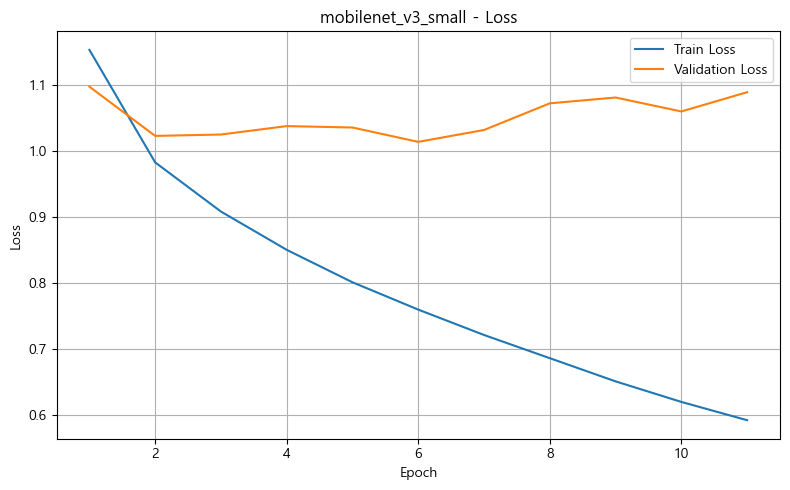

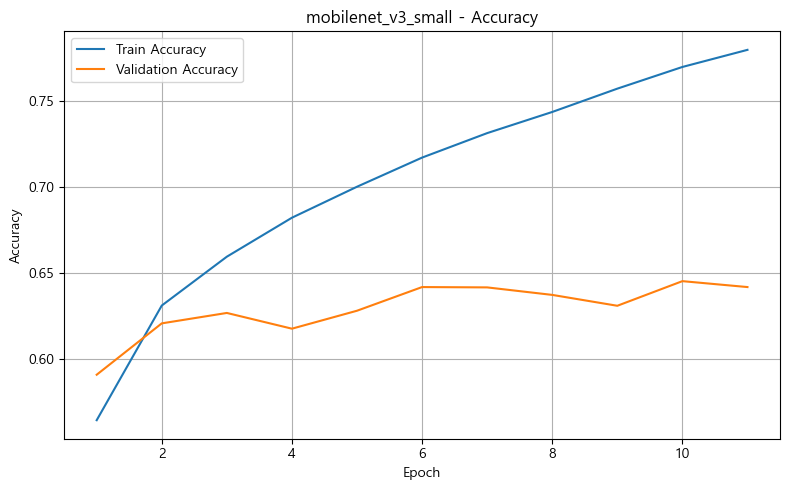

Best model 경로: D:\emotion_recognition_project\05_models\mobilenet_v3_small_pretrained_best.pt
History CSV 경로: D:\emotion_recognition_project\06_outputs\mobilenet_v3_small_pretrained_history.csv


C:\Users\USER\AppData\Local\Temp\ipykernel_69820\2156406771.py:4: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(best_model_path, map_locatio


[mobilenet_v3_small] Best model Validation 평가
Accuracy: 0.6418


,class,precision,recall,f1_score
0,기쁨,0.905807,0.929724,0.917610
1,당황,0.685514,0.709149,0.697132
2,분노,0.606047,0.717330,0.657010
3,불안,0.567707,0.297151,0.390110
4,상처,0.388752,0.424626,0.405898
5,슬픔,0.629474,0.639658,0.634525
6,중립,0.687184,0.770634,0.726520


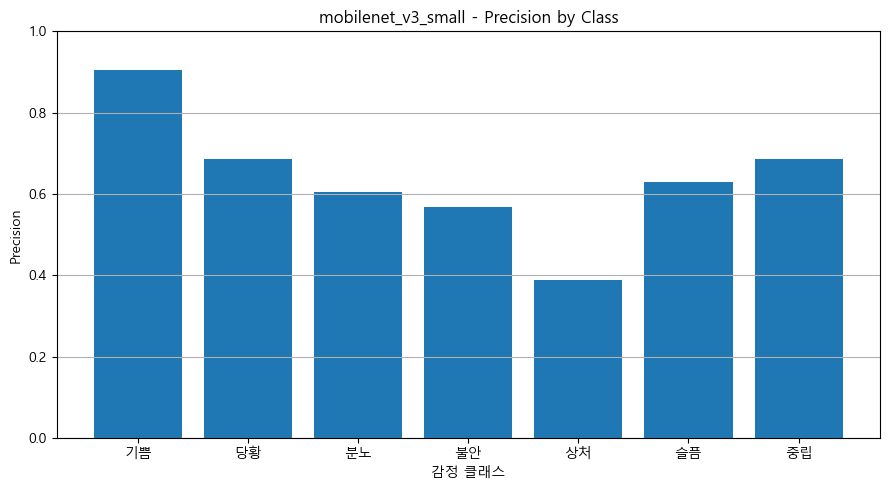

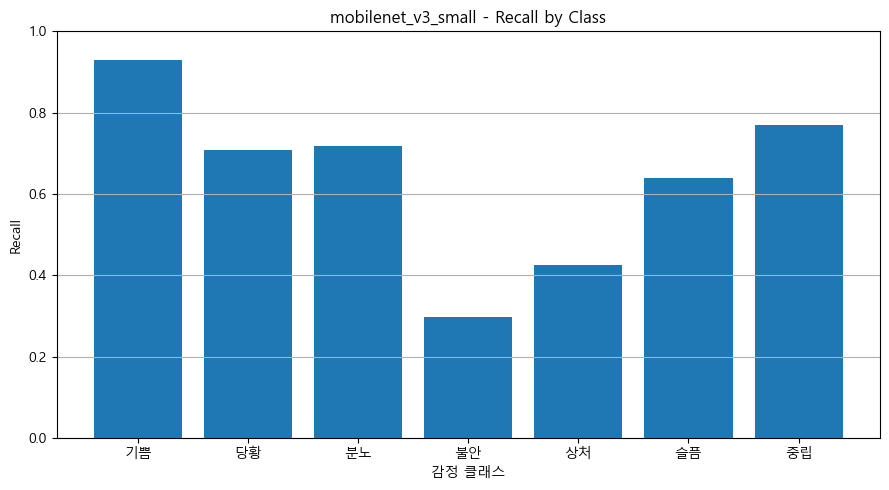

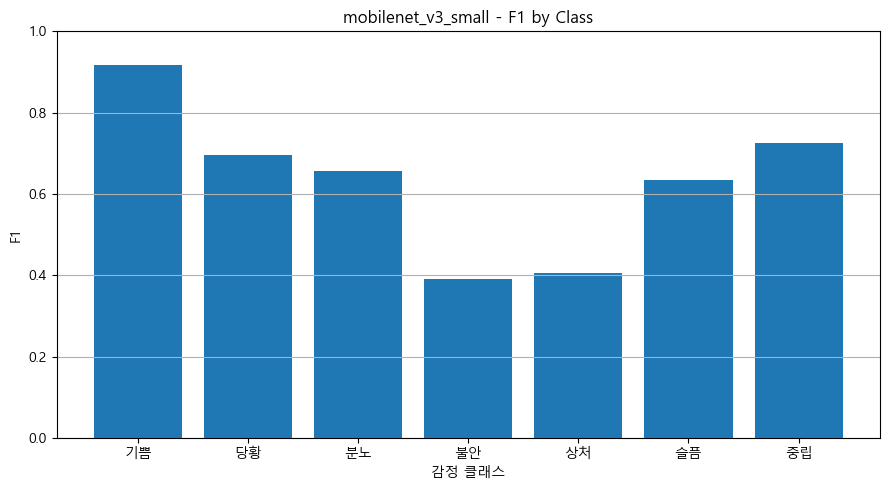

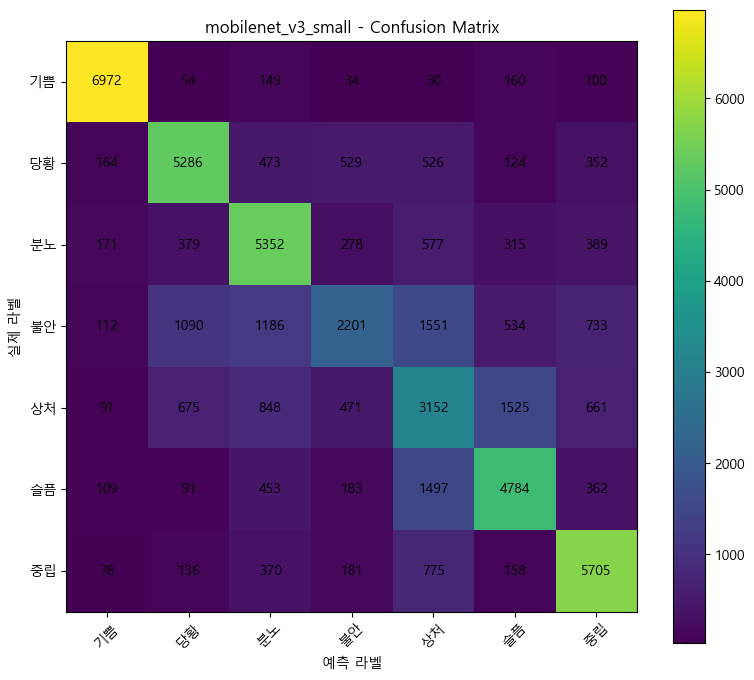

In [18]:
# 4-1. MobileNetV3 Small
mobilenet_history, mobilenet_best_path = train_model(
    model_name="mobilenet_v3_small",
    train_loader=train_loader,
    valid_loader=valid_loader,
    device=device,
    max_epochs=30,
    patience=5,
    learning_rate=0.001,
)

mobilenet_result = evaluate_best_model(
    model_name="mobilenet_v3_small",
    valid_loader=valid_loader,
    device=device,
    best_model_path=mobilenet_best_path,
)


### 4-2. EfficientNetB0 본학습

같은 조건으로 EfficientNetB0을 학습한다.


===== efficientnet_b0 학습 시작 =====
Epoch 01 | train_loss=1.0020 | train_acc=0.6260 | valid_loss=1.0054 | valid_acc=0.6315 | 1056.5s
  -> Best model 저장: efficientnet_b0_pretrained_best.pt
Epoch 02 | train_loss=0.8213 | train_acc=0.6947 | valid_loss=0.8837 | valid_acc=0.6805 | 1070.4s
  -> Best model 저장: efficientnet_b0_pretrained_best.pt
Epoch 03 | train_loss=0.7323 | train_acc=0.7290 | valid_loss=0.8884 | valid_acc=0.6823 | 1063.5s
  -> Validation loss 개선 없음 (1/5)
Epoch 04 | train_loss=0.6644 | train_acc=0.7540 | valid_loss=0.8739 | valid_acc=0.6910 | 1054.0s
  -> Best model 저장: efficientnet_b0_pretrained_best.pt
Epoch 05 | train_loss=0.6092 | train_acc=0.7757 | valid_loss=0.9072 | valid_acc=0.6903 | 1065.6s
  -> Validation loss 개선 없음 (1/5)
Epoch 06 | train_loss=0.5610 | train_acc=0.7935 | valid_loss=0.9388 | valid_acc=0.6958 | 1054.6s
  -> Validation loss 개선 없음 (2/5)
Epoch 07 | train_loss=0.5189 | train_acc=0.8090 | valid_loss=0.8959 | valid_acc=0.7049 | 1052.9s
  -> Validation loss 개

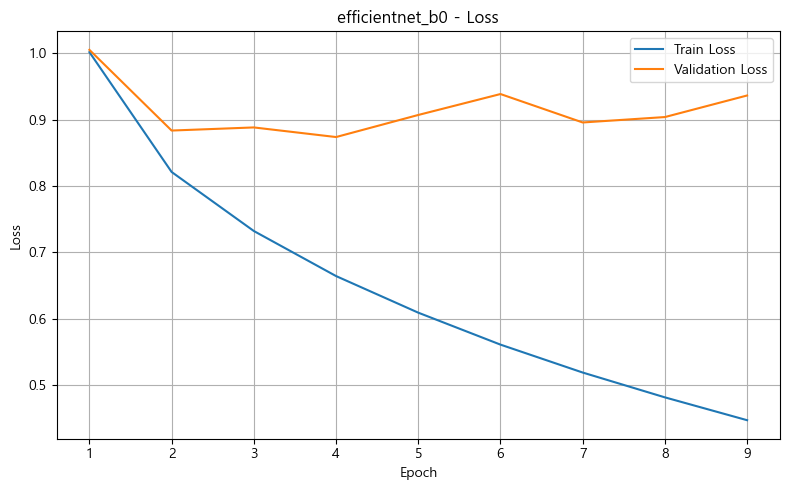

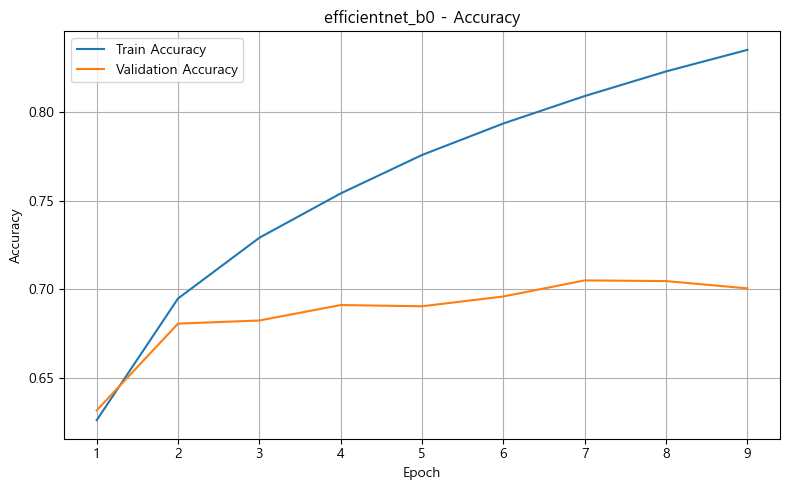

Best model 경로: D:\emotion_recognition_project\05_models\efficientnet_b0_pretrained_best.pt
History CSV 경로: D:\emotion_recognition_project\06_outputs\efficientnet_b0_pretrained_history.csv


C:\Users\USER\AppData\Local\Temp\ipykernel_69820\2156406771.py:4: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(best_model_path, map_locatio


[efficientnet_b0] Best model Validation 평가
Accuracy: 0.691


,class,precision,recall,f1_score
0,기쁨,0.932027,0.945326,0.938630
1,당황,0.785919,0.663402,0.719482
2,분노,0.635295,0.804316,0.709883
3,불안,0.527572,0.501148,0.514021
4,상처,0.515530,0.377880,0.436101
5,슬픔,0.684290,0.662789,0.673368
6,중립,0.718464,0.879373,0.790816


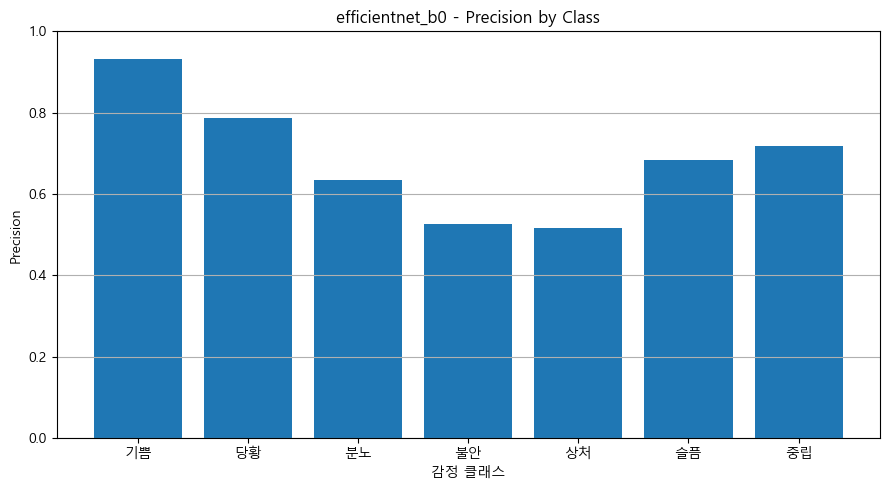

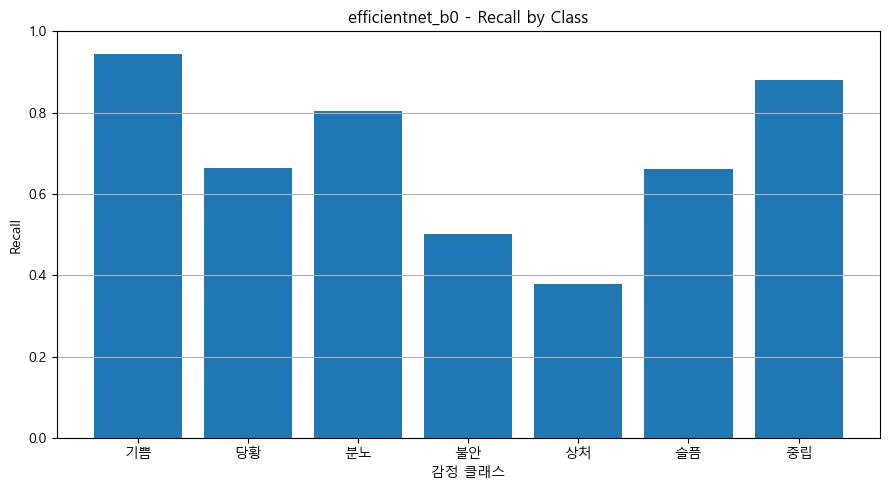

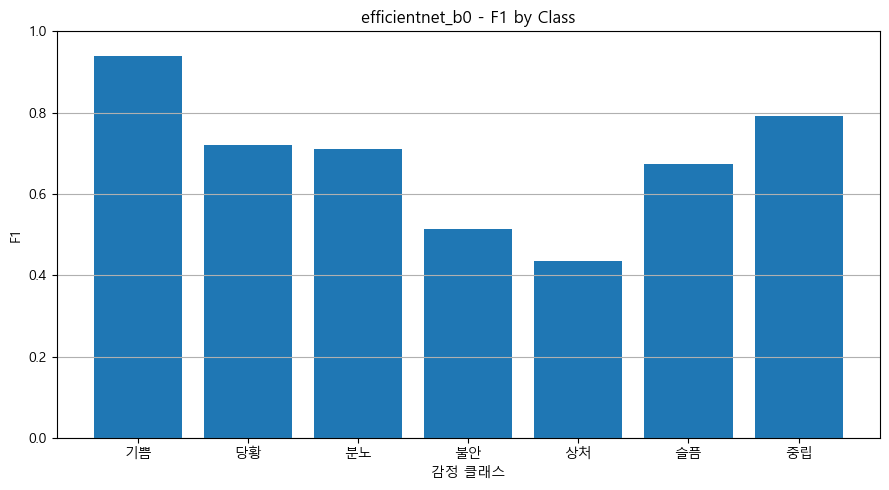

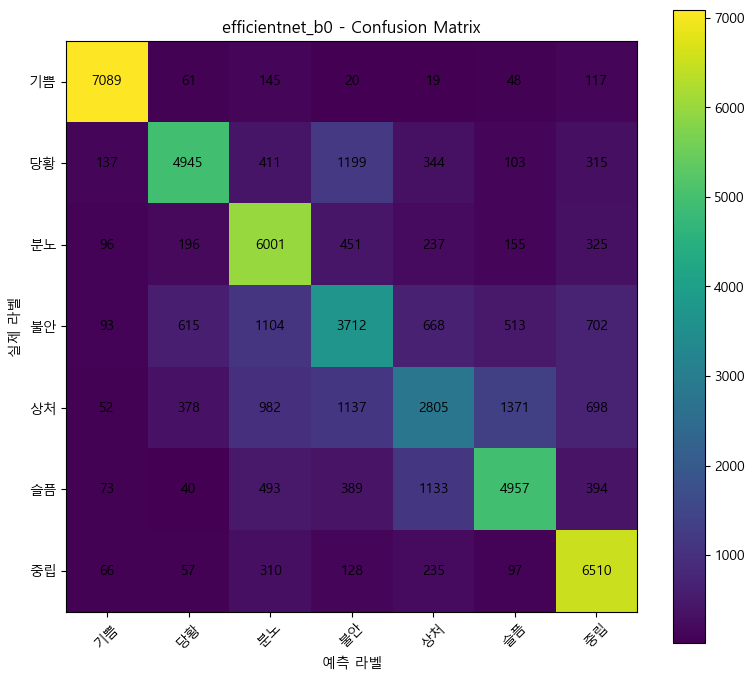

In [19]:
# 4-2. EfficientNetB0
efficientnet_history, efficientnet_best_path = train_model(
    model_name="efficientnet_b0",
    train_loader=train_loader,
    valid_loader=valid_loader,
    device=device,
    max_epochs=30,
    patience=5,
    learning_rate=0.001,
)

efficientnet_result = evaluate_best_model(
    model_name="efficientnet_b0",
    valid_loader=valid_loader,
    device=device,
    best_model_path=efficientnet_best_path,
)


### 4-3. ResNet18 본학습

마지막으로 같은 조건에서 ResNet18을 학습한다.


===== resnet18 학습 시작 =====
Epoch 01 | train_loss=1.0631 | train_acc=0.6025 | valid_loss=1.0256 | valid_acc=0.6232 | 837.7s
  -> Best model 저장: resnet18_pretrained_best.pt
Epoch 02 | train_loss=0.8644 | train_acc=0.6780 | valid_loss=0.9418 | valid_acc=0.6578 | 835.3s
  -> Best model 저장: resnet18_pretrained_best.pt
Epoch 03 | train_loss=0.7589 | train_acc=0.7177 | valid_loss=0.9608 | valid_acc=0.6586 | 834.9s
  -> Validation loss 개선 없음 (1/5)
Epoch 04 | train_loss=0.6724 | train_acc=0.7496 | valid_loss=0.9091 | valid_acc=0.6792 | 835.2s
  -> Best model 저장: resnet18_pretrained_best.pt
Epoch 05 | train_loss=0.5903 | train_acc=0.7800 | valid_loss=0.9351 | valid_acc=0.6794 | 835.0s
  -> Validation loss 개선 없음 (1/5)
Epoch 06 | train_loss=0.5095 | train_acc=0.8102 | valid_loss=0.9870 | valid_acc=0.6754 | 835.0s
  -> Validation loss 개선 없음 (2/5)
Epoch 07 | train_loss=0.4321 | train_acc=0.8392 | valid_loss=1.0551 | valid_acc=0.6851 | 834.2s
  -> Validation loss 개선 없음 (3/5)
Epoch 08 | train_loss=0.

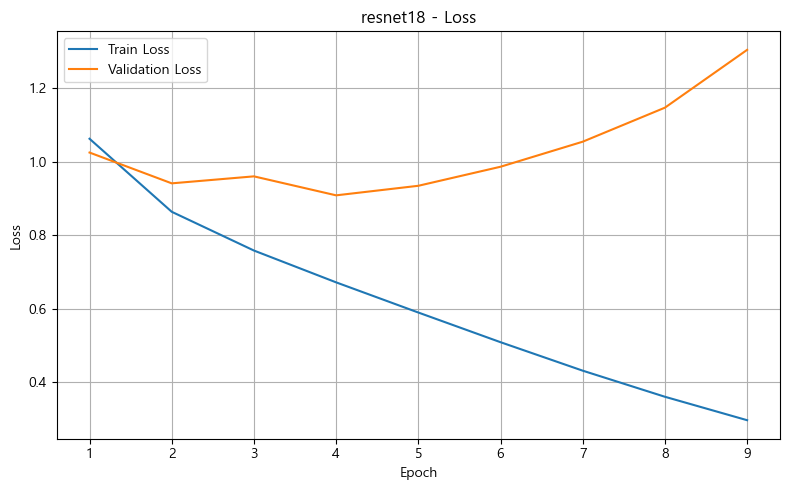

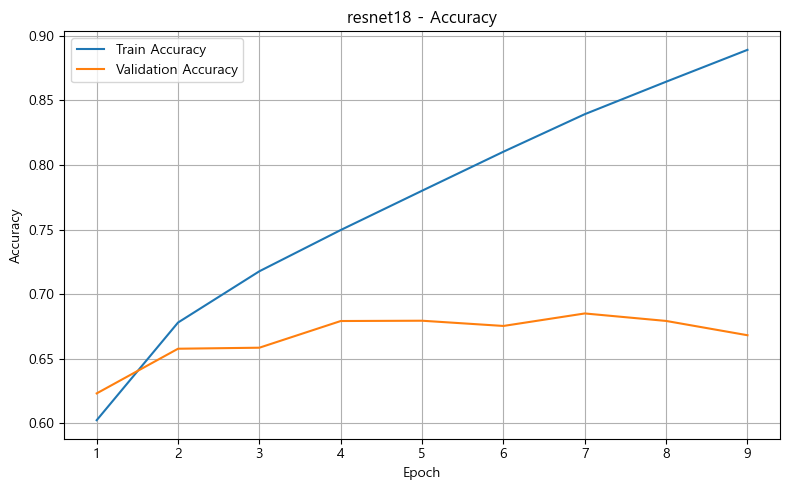

Best model 경로: D:\emotion_recognition_project\05_models\resnet18_pretrained_best.pt
History CSV 경로: D:\emotion_recognition_project\06_outputs\resnet18_pretrained_history.csv


C:\Users\USER\AppData\Local\Temp\ipykernel_69820\2156406771.py:4: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(best_model_path, map_locatio


[resnet18] Best model Validation 평가
Accuracy: 0.6792


,class,precision,recall,f1_score
0,기쁨,0.925936,0.950260,0.937940
1,당황,0.676208,0.773276,0.721492
2,분노,0.692747,0.731001,0.711360
3,불안,0.512632,0.432834,0.469365
4,상처,0.444709,0.428533,0.436471
5,슬픔,0.739976,0.574943,0.647103
6,중립,0.723086,0.861002,0.786040


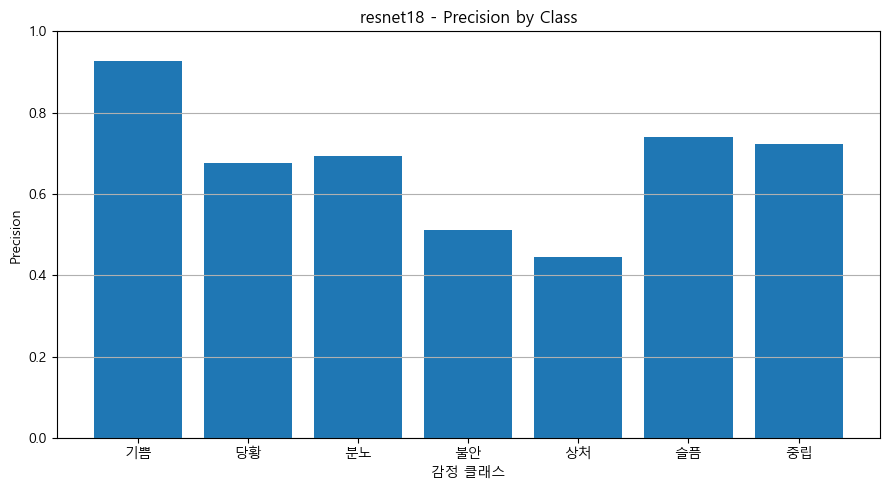

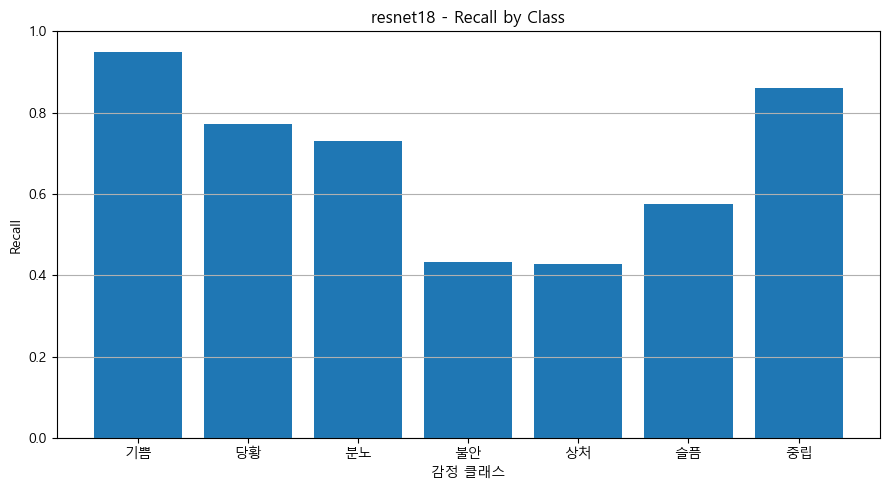

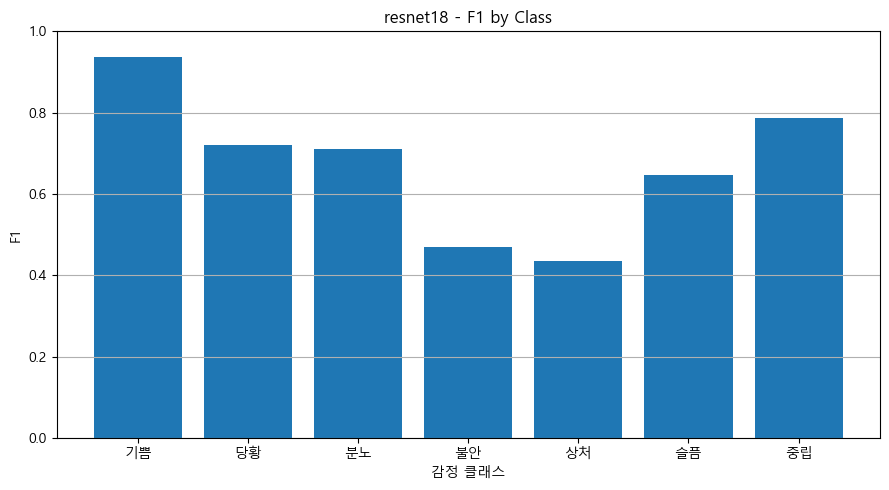

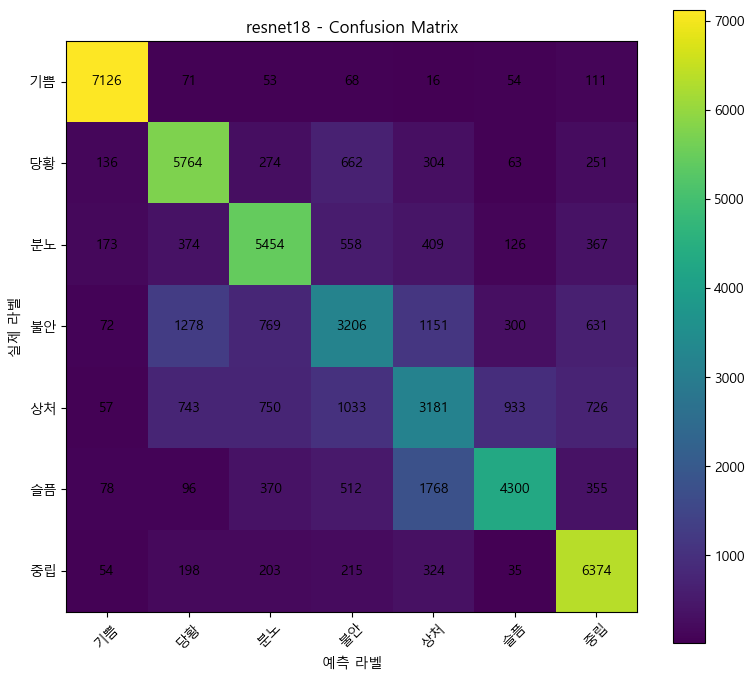

In [20]:
# 4-3. ResNet18
resnet_history, resnet_best_path = train_model(
    model_name="resnet18",
    train_loader=train_loader,
    valid_loader=valid_loader,
    device=device,
    max_epochs=30,
    patience=5,
    learning_rate=0.001,
)

resnet_result = evaluate_best_model(
    model_name="resnet18",
    valid_loader=valid_loader,
    device=device,
    best_model_path=resnet_best_path,
)


## 5. 세 모델 최종 비교

세 모델의 Validation 평가 결과를 하나의 표와 그래프로 비교한다.

비교 항목:
- Accuracy
- 평균 Precision
- 평균 Recall
- 평균 F1-score
- Best Validation Loss

모든 비교 결과는 `06_outputs/`에 CSV와 PNG로 저장한다.

,model,accuracy,mean_precision,mean_recall,mean_f1
0,mobilenet_v3_small,0.641753,0.638641,0.641182,0.632686
1,efficientnet_b0,0.690999,0.685585,0.690605,0.683186
2,resnet18,0.679220,0.673613,0.678836,0.672825


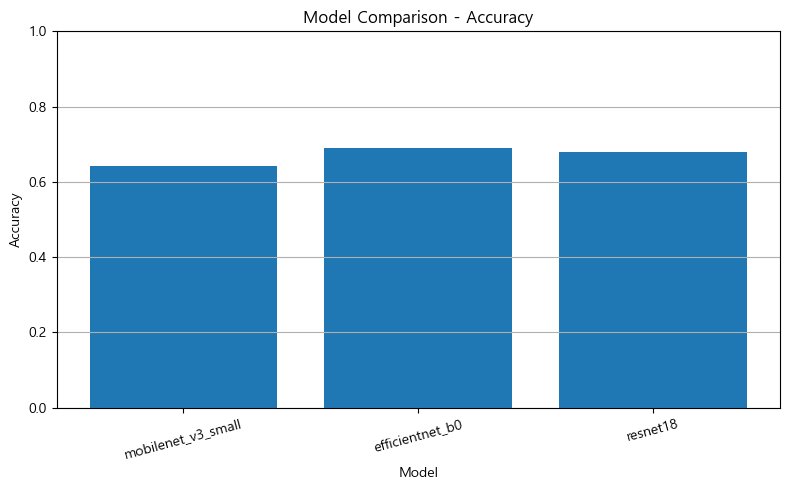

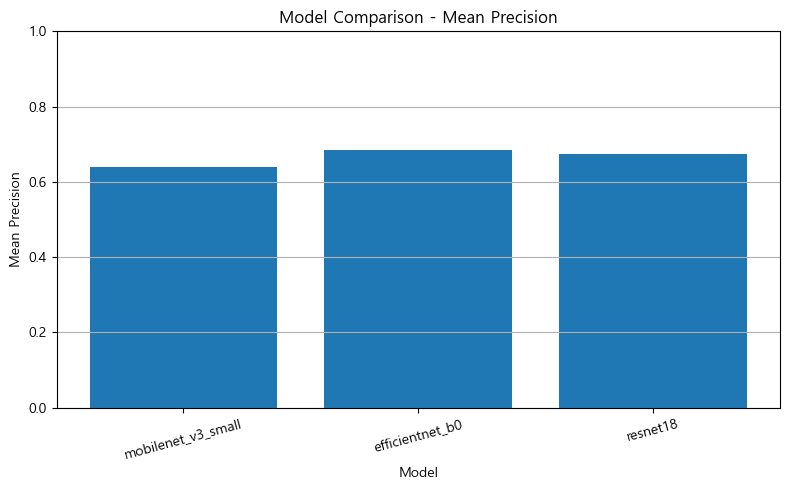

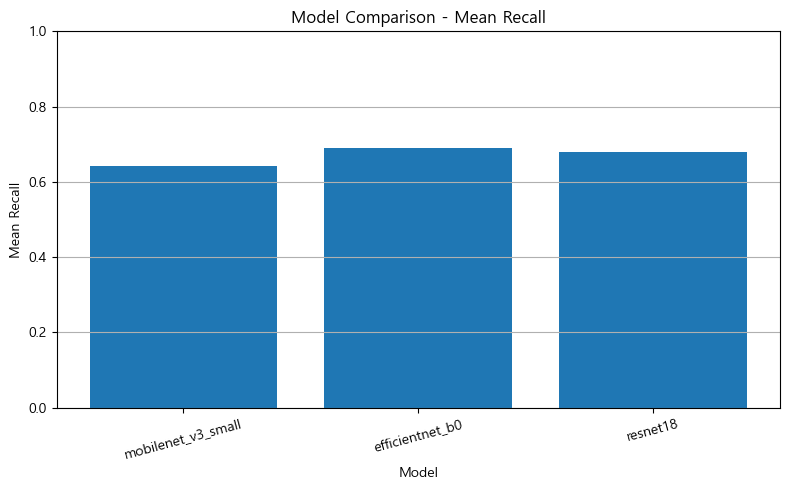

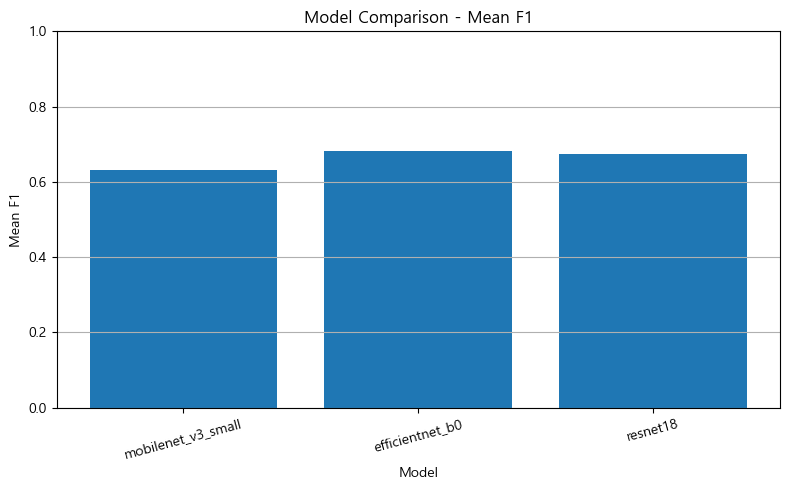

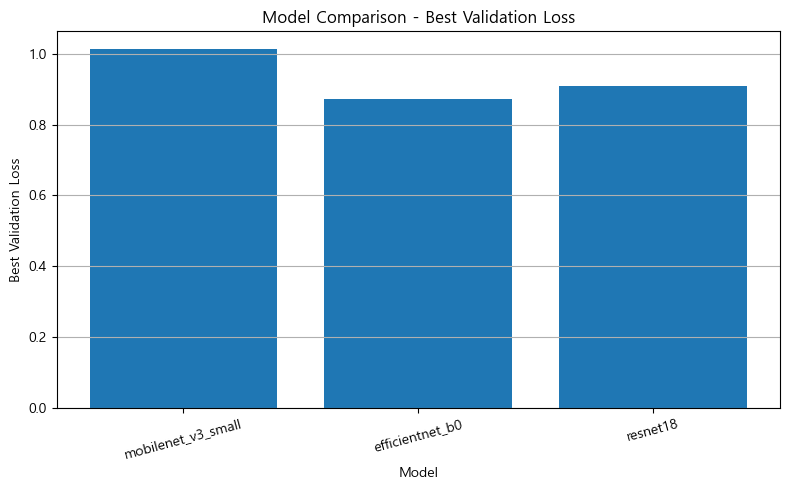


세 모델 학습 및 평가 종료
모델 저장 폴더: D:\emotion_recognition_project\05_models
결과 저장 폴더: D:\emotion_recognition_project\06_outputs
비교 결과 CSV: D:\emotion_recognition_project\06_outputs\pretrained_model_comparison_metrics.csv


In [21]:
# --------------------------------------------------
# 세 모델 최종 비교
# --------------------------------------------------
model_results = [
    mobilenet_result,
    efficientnet_result,
    resnet_result,
]

results_df = pd.DataFrame(model_results)

results_path = OUTPUT_DIR / "pretrained_model_comparison_metrics.csv"
results_df.to_csv(
    results_path,
    index=False,
    encoding="utf-8-sig",
)

display(results_df)

comparison_metrics = [
    ("accuracy", "Accuracy"),
    ("mean_precision", "Mean Precision"),
    ("mean_recall", "Mean Recall"),
    ("mean_f1", "Mean F1"),
]

# 보기로 한 최종 평가지표별로 각각 비교 그래프 생성
for column, title in comparison_metrics:
    plt.figure(figsize=(8, 5))
    plt.bar(results_df["model"], results_df[column])
    plt.ylim(0, 1)
    plt.xlabel("Model")
    plt.ylabel(title)
    plt.title(f"Model Comparison - {title}")
    plt.xticks(rotation=15)
    plt.grid(axis="y")
    plt.tight_layout()

    graph_path = OUTPUT_DIR / f"pretrained_model_comparison_{column}.png"
    plt.savefig(graph_path, dpi=150)
    plt.show()
    plt.close()

# Best validation loss 비교
best_loss_df = pd.DataFrame([
    {
        "model": "mobilenet_v3_small",
        "best_valid_loss": mobilenet_history["valid_loss"].min(),
    },
    {
        "model": "efficientnet_b0",
        "best_valid_loss": efficientnet_history["valid_loss"].min(),
    },
    {
        "model": "resnet18",
        "best_valid_loss": resnet_history["valid_loss"].min(),
    },
])

plt.figure(figsize=(8, 5))
plt.bar(best_loss_df["model"], best_loss_df["best_valid_loss"])
plt.xlabel("Model")
plt.ylabel("Best Validation Loss")
plt.title("Model Comparison - Best Validation Loss")
plt.xticks(rotation=15)
plt.grid(axis="y")
plt.tight_layout()
plt.savefig(
    OUTPUT_DIR / "pretrained_model_comparison_best_valid_loss.png",
    dpi=150,
)
plt.show()
plt.close()

print("\n세 모델 학습 및 평가 종료")
print("모델 저장 폴더:", MODEL_DIR)
print("결과 저장 폴더:", OUTPUT_DIR)
print("비교 결과 CSV:", results_path)


### 발표 때 설명할 핵심

1. **왜 PyTorch를 사용했나?**  
   직능원 Windows 환경에서 TensorFlow가 RTX 4060 GPU를 인식하지 못해,
   CUDA가 정상 인식되는 PyTorch로 본학습 환경을 전환했다.
   현재 학습은 집 PC의 RTX 3070에서 실행하고, 최종 시연 환경은 직능원 PC에서 다시 검증한다.

2. **왜 grayscale인데 3채널인가?**  
   전처리 결과는 실제로 1채널 흑백이고, torchvision 모델의 입력 구조를 맞추기 위해
   같은 흑백 값을 3채널에 복제한다. 이후 ImageNet 사전학습 가중치에 맞게 정규화하며,
   이는 컬러 정보를 복원하는 과정은 아니다.

3. **왜 ImageNet 사전학습 가중치를 사용했나?**  
   `weights=None`으로 처음부터 학습한 MobileNetV3 Small이 여러 Epoch 동안
   Train/Validation Accuracy 약 14% 수준에 머물러 학습이 거의 진행되지 않았다.
   진단 결과 데이터 연결, 라벨, 입력 Tensor, 역전파 코드는 정상적으로 동작했고,
   작은 Batch는 모델이 충분히 학습할 수 있음을 확인했다.
   따라서 일반적인 시각 특징을 이미 학습한 ImageNet DEFAULT 가중치에서 시작해
   세 모델을 동일 조건으로 Fine-tuning하는 방식으로 변경했다.

4. **왜 CrossEntropyLoss를 사용했나?**  
   한 이미지가 7개 감정 중 하나에 속하는 다중분류 문제이므로 CrossEntropyLoss를 사용했다.

5. **어떤 지표로 평가했나?**  
   학습 과정에서는 Loss와 Accuracy를 확인하고,
   Best model에서는 같은 Validation set으로 Accuracy, 클래스별 Precision, Recall, F1-score와 Confusion Matrix를 확인한다.

6. **그래프는 왜 만들었나?**  
   Loss/Accuracy 곡선으로 학습과 과적합 여부를 보고,
   Precision/Recall/F1 그래프로 감정별 성능 차이를 확인하며,
   Confusion Matrix로 어떤 감정끼리 자주 혼동하는지 분석하기 위해서다.

7. **왜 모델별 셀을 나눴나?**  
   세 모델을 같은 조건으로 비교하되, 학습 진행 상황과 결과를 모델별로 쉽게 확인하기 위해
   MobileNetV3 Small / EfficientNetB0 / ResNet18 실행 구역을 따로 나눴다.

8. **왜 'Validation 평가 결과'라고 표현하나?**  
   현재 프로젝트에서는 별도의 Test set을 추가하지 않고,
   Validation set을 EarlyStopping과 Best model 선택에 사용한 뒤
   같은 Validation set에서 Accuracy / Precision / Recall / F1 / Confusion Matrix를 확인한다.
   따라서 발표에서는 **Best model의 Validation 평가 결과**라고 표현한다.